In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, GRU, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

ENGINE_ID = 23

np.random.seed(318)
tf.random.set_seed(318)

In [2]:
index_names = ['id', 'cycle']
setting_names = ['setting1', 'setting2', 'setting3']
sensor_names = [f's{i}' for i in range(1, 22)] # s1 ... s21
col_names = index_names + setting_names + sensor_names

# --- ЗАГРУЗКА TRAIN ---
train_df = pd.read_csv('PM_train.txt', sep=" ", header=None)
train_df.drop(train_df.columns[[26, 27]], axis=1, inplace=True)
train_df.columns = col_names

train_df = train_df[train_df['id'] == ENGINE_ID]


# --- ЗАГРУЗКА TEST ---
test_df = pd.read_csv('PM_test.txt', sep=" ", header=None)
test_df.drop(test_df.columns[[26, 27]], axis=1, inplace=True)
test_df.columns = col_names

test_df = test_df[test_df['id'] == ENGINE_ID]


# --- ЗАГРУЗКА TRUTH ---
truth_df = pd.read_csv('PM_truth.txt', sep=" ", header=None)
truth_df.drop(truth_df.columns[[1]], axis=1, inplace=True)
truth_df.columns = ['max']

truth_df = truth_df.iloc[[ENGINE_ID - 1]]

train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
truth_df.reset_index(drop=True, inplace=True)

print(f"Данные загружены для двигателя №{ENGINE_ID}")
print(f"Размер Train: {train_df.shape}")
print(f"Размер Test: {test_df.shape}")
print(f"Truth RUL: {truth_df.iloc[0,0]}")

truth_df.head()

Данные загружены для двигателя №23
Размер Train: (168, 26)
Размер Test: (130, 26)
Truth RUL: 113


,max
0,113


In [3]:
# сортировка
train_df = train_df.sort_values(['id', 'cycle'])

# RUL = max_cycle(id) - cycle
rul = train_df.groupby('id')['cycle'].max().reset_index()
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on='id', how='left')
train_df['RUL'] = train_df['max'] - train_df['cycle']
train_df.drop('max', axis=1, inplace=True)

# пороги
w1 = 30
w0 = 15

train_df['label1'] = np.where(train_df['RUL'] <= w1, 1, 0)
train_df['label2'] = train_df['label1']
train_df.loc[train_df['RUL'] <= w0, 'label2'] = 2

train_df['cycle_norm'] = train_df['cycle']
cols_normalize = train_df.columns.difference(['id', 'cycle', 'RUL', 'label1', 'label2'])
min_max_scaler = preprocessing.MinMaxScaler()

norm_train_df = pd.DataFrame(
    min_max_scaler.fit_transform(train_df[cols_normalize]),
    columns=cols_normalize,
    index=train_df.index
)

join_df = train_df[train_df.columns.difference(cols_normalize)].join(norm_train_df)
train_df = join_df.reindex(columns=train_df.columns)
train_df.head()

,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s16,s17,s18,s19,s20,s21,RUL,label1,label2,cycle_norm
0,23,1,0.796610,1.0,0.0,0.0,0.009479,0.417688,0.318803,0.0,...,0.0,0.500000,0.0,0.0,0.629213,0.631451,167,0,0,0.000000
1,23,2,0.584746,0.6,0.0,0.0,0.189573,0.467163,0.441732,0.0,...,0.0,0.666667,0.0,0.0,0.651685,0.683928,166,0,0,0.005988
2,23,3,0.406780,0.9,0.0,0.0,0.364929,0.429510,0.259227,0.0,...,0.0,0.166667,0.0,0.0,0.617978,0.660201,165,0,0,0.011976
3,23,4,0.652542,0.5,0.0,0.0,0.559242,0.107706,0.179599,0.0,...,0.0,0.166667,0.0,0.0,0.629213,0.739522,164,0,0,0.017964
4,23,5,0.550847,0.8,0.0,0.0,0.597156,0.358581,0.276083,0.0,...,0.0,0.333333,0.0,0.0,0.707865,0.651715,163,0,0,0.023952


In [4]:
# нормализация теста теми же параметрами
test_df['cycle_norm'] = test_df['cycle']
norm_test_df = pd.DataFrame(
    min_max_scaler.transform(test_df[cols_normalize]),
    columns=cols_normalize,
    index=test_df.index
)
test_join_df = test_df[test_df.columns.difference(cols_normalize)].join(norm_test_df)
test_df = test_join_df.reindex(columns=test_df.columns)
test_df = test_df.reset_index(drop=True)

# генерация RUL для теста
test_df = test_df.merge(
    truth_df,
    left_on=test_df.groupby('id')['cycle'].transform('max') == test_df['cycle'],
    right_index=True,
    how='left'
)

# переносим max по id
test_rul = truth_df.copy()
test_rul['id'] = range(1, len(test_rul) + 1)
test_df = test_df.merge(test_rul, on='id', how='left', suffixes=('', '_truth'))
test_df['RUL'] = test_df['max'] - test_df['cycle']
test_df.drop(['max'], axis=1, inplace=True)

# метки
test_df['label1'] = np.where(test_df['RUL'] <= w1, 1, 0)
test_df['label2'] = test_df['label1']
test_df.loc[test_df['RUL'] <= w0, 'label2'] = 2

test_df.head()

,key_0,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,...,s17,s18,s19,s20,s21,cycle_norm,max_truth,RUL,label1,label2
0,False,23,1,0.788136,0.1,0.0,0.0,0.146919,-0.513135,-0.072653,...,-0.166667,0.0,0.0,0.943820,0.895393,0.000000,NaN,112.0,0,0
1,False,23,2,0.762712,0.3,0.0,0.0,0.142180,0.190455,-0.017437,...,0.333333,0.0,0.0,0.988764,0.913751,0.005988,NaN,111.0,0,0
2,False,23,3,0.830508,0.6,0.0,0.0,0.142180,0.133100,-0.142400,...,-0.166667,0.0,0.0,0.966292,0.885175,0.011976,NaN,110.0,0,0
3,False,23,4,0.635593,0.6,0.0,0.0,0.161137,0.033713,-0.111014,...,0.000000,0.0,0.0,0.876404,0.954451,0.017964,NaN,109.0,0,0
4,False,23,5,0.322034,1.0,0.0,0.0,0.118483,0.169002,0.203720,...,0.166667,0.0,0.0,1.000000,0.777624,0.023952,NaN,108.0,0,0


In [5]:
# длина временного окна
sequence_length = 50

# признаки
sensor_cols = [f's{i}' for i in range(1, 22)]
sequence_cols =  ['setting1', 'setting2', 'setting3', 'cycle_norm'] + sensor_cols

len(sequence_cols), sequence_cols[:5]

(25, ['setting1', 'setting2', 'setting3', 'cycle_norm', 's1'])

In [6]:
# генерация последовательностей (как в оригинальном ноутбуке)
def gen_sequence(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length),
                           range(seq_length, num_elements)):
        yield data_array[start:stop, :]

# генерируем для всех двигателей
seq_gen = (list(gen_sequence(train_df[train_df['id'] == id_],
                             sequence_length,
                             sequence_cols))
           for id_ in train_df['id'].unique())

seq_array = np.concatenate(list(seq_gen)).astype(np.float32)
seq_array.shape

(118, 50, 25)

In [7]:
# генерация меток для обучающих последовательностей
def gen_labels(id_df, seq_length, label_cols):
    data_array = id_df[label_cols].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements, :]

label_gen = [gen_labels(train_df[train_df['id'] == id_],
                        sequence_length,
                        ['label1'])
             for id_ in train_df['id'].unique()]

label_array = np.concatenate(label_gen).astype(np.float32)
label_array.shape

(118, 1)

In [8]:
# берём последние sequence_length шагов по каждому двигателю
seq_array_test_last = [
    test_df[test_df['id'] == id_][sequence_cols].values[-sequence_length:]
    for id_ in test_df['id'].unique()
    if len(test_df[test_df['id'] == id_]) >= sequence_length
]

seq_array_test_last = np.asarray(seq_array_test_last).astype(np.float32)
seq_array_test_last.shape

(1, 50, 25)

In [9]:
# маска тех id, у кого длина >= sequence_length, чтобы взять правильные метки
y_mask = [
    len(test_df[test_df['id'] == id_]) >= sequence_length
    for id_ in test_df['id'].unique()
]

label_array_test_last = test_df.groupby('id')['label1'].nth(-1)[y_mask].values
label_array_test_last = label_array_test_last.reshape(-1, 1).astype(np.float32)
label_array_test_last.shape

(1, 1)

In [10]:
nb_features = seq_array.shape[2]
nb_out = label_array.shape[1]

def build_model(model_type, input_shape, nb_out):
    """
    model_type: 'LSTM', 'GRU', 'RNN'
    """
    if model_type == 'LSTM':
        Layer = LSTM
    elif model_type == 'GRU':
        Layer = GRU
    elif model_type == 'RNN':
        Layer = SimpleRNN
    else:
        raise ValueError("model_type must be 'LSTM', 'GRU' or 'RNN'")

    model = Sequential()
    model.add(Layer(
        input_shape=input_shape,
        units=100,
        return_sequences=True
    ))
    model.add(Dropout(0.2))

    model.add(Layer(
        units=50,
        return_sequences=False
    ))
    model.add(Dropout(0.2))

    model.add(Dense(units=nb_out, activation='sigmoid'))
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


In [11]:
def train_and_evaluate(model_type, seed,
                       X_train, y_train,
                       X_test, y_test,
                       epochs=10, batch_size=200):

    # фиксация сидов
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_model(model_type, (sequence_length, nb_features), nb_out)
    print(f"\n=== {model_type}, seed={seed} ===")
    print(model.summary())

    es = EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=0,
        verbose=1,
        restore_best_weights=True
    )

    # измеряем время обучения
    import time
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.05,
        verbose=1,
        callbacks=[es]
    )

    train_time = time.time() - start_time
    print(f"Train time: {train_time:.2f} sec")

    # --- метрики на train ---
    y_train_pred_prob = model.predict(X_train).ravel()
    y_train_pred = (y_train_pred_prob > 0.1).astype(int)
    y_train_true = y_train.ravel()

    loss_train, acc_train = model.evaluate(X_train, y_train, verbose=0)

    prec_train = precision_score(y_train_true, y_train_pred)
    rec_train = recall_score(y_train_true, y_train_pred)
    f1_train = f1_score(y_train_true, y_train_pred)

    # --- метрики на test ---
    y_test_pred_prob = model.predict(X_test).ravel()
    y_test_pred = (y_test_pred_prob > 0.1).astype(int)
    y_test_true = y_test.ravel()

    loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)

    prec_test = precision_score(y_test_true, y_test_pred)
    rec_test = recall_score(y_test_true, y_test_pred)
    f1_test = f1_score(y_test_true, y_test_pred)

    metrics = {
        'model_type': model_type,
        'seed': seed,
        'loss_train': loss_train,
        'acc_train': acc_train,
        'precision_train': prec_train,
        'recall_train': rec_train,
        'f1_train': f1_train,
        'loss_test': loss_test,
        'acc_test': acc_test,
        'precision_test': prec_test,
        'recall_test': rec_test,
        'f1_test': f1_test,
        'train_time_sec': train_time,
        'history': history
    }

    return model, metrics


In [12]:
seeds = [318]
model_types = ['LSTM', 'GRU', 'RNN']

all_results = []
best_model = None
best_result = None

for m_type in model_types:
    for seed in seeds:
        model, metrics = train_and_evaluate(
            m_type, seed,
            seq_array, label_array,
            seq_array_test_last, label_array_test_last,
            epochs=10,
            batch_size=200
        )
        all_results.append(metrics)
        if (best_result is None) or (metrics['f1_test'] > best_result['f1_test']):
            best_result = metrics
            best_model = model

results_df = pd.DataFrame([
    {k: v for k, v in d.items() if k != 'history'}
    for d in all_results
])
results_df



=== LSTM, seed=318 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 100)        │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,651 (315.04 KB)

...

None
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7143 - loss: 0.5719 - val_accuracy: 0.0000e+00 - val_loss: 1.2640
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7679 - loss: 0.5177 - val_accuracy: 0.0000e+00 - val_loss: 0.9604
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7768 - loss: 0.4511 - val_accuracy: 0.8333 - val_loss: 0.6000
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8304 - loss: 0.3693 - val_accuracy: 1.0000 - val_loss: 0.4090
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9018 - loss: 0.3021 - val_accuracy: 1.0000 - val_loss: 0.3286
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9286 - loss: 0.2683 - val_accuracy: 1.0000 - val_loss: 0.2789
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9286 - loss: 0.2091 - val_accuracy: 1.0000 - val_loss: 0.1910
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9464 - loss: 0.1780 - val_accuracy: 1.0000 -

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model_type,seed,loss_train,acc_train,precision_train,recall_train,f1_train,loss_test,acc_test,precision_test,recall_test,f1_test,train_time_sec
0,LSTM,318,0.636339,0.737288,0.262712,1.0,0.416107,0.578421,1.0,0.0,0.0,0.0,4.449758
1,GRU,318,0.643763,0.737288,0.262712,1.0,0.416107,0.551050,1.0,0.0,0.0,0.0,5.139285
2,RNN,318,0.112726,0.957627,1.000000,1.0,1.000000,0.021172,1.0,0.0,0.0,0.0,4.373394


In [13]:
print("Лучший вариант по F1 на тесте:")
{k: v for k, v in best_result.items() if k != 'history'}

Лучший вариант по F1 на тесте:


{'model_type': 'LSTM',
 'seed': 318,
 'loss_train': 0.6363391280174255,
 'acc_train': 0.7372881174087524,
 'precision_train': 0.2627118644067797,
 'recall_train': 1.0,
 'f1_train': 0.4161073825503356,
 'loss_test': 0.5784208178520203,
 'acc_test': 1.0,
 'precision_test': 0.0,
 'recall_test': 0.0,
 'f1_test': 0.0,
 'train_time_sec': 4.4497575759887695}

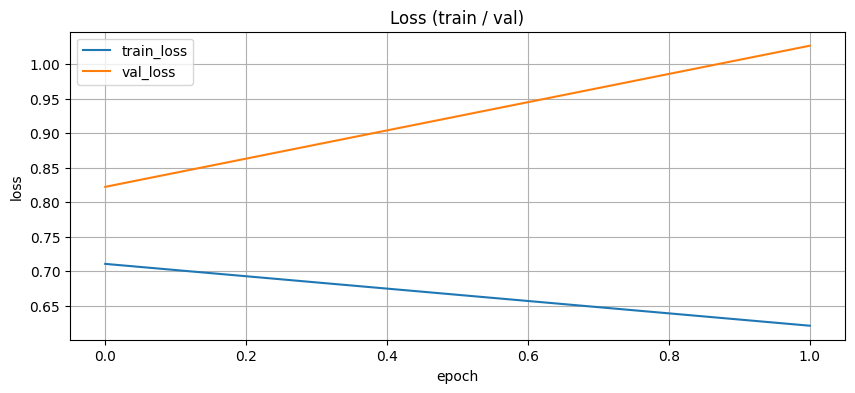

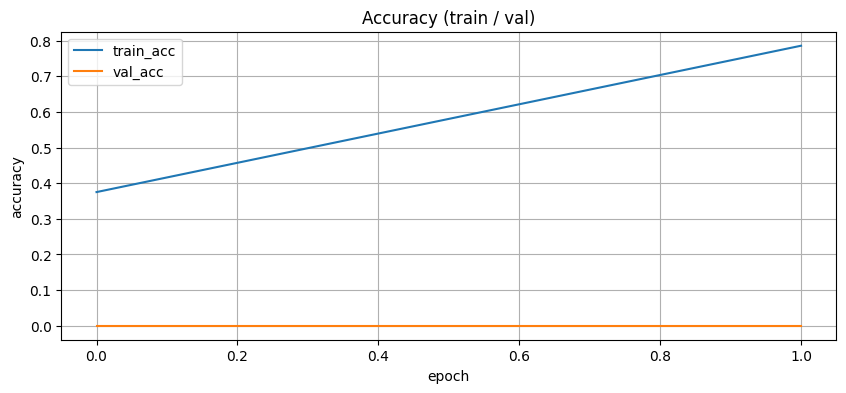

In [14]:
best_history = best_result['history']
hist = best_history.history

plt.figure(figsize=(10,4))
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss (train / val)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy (train / val)')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# train
y_train_true = label_array.ravel()
y_train_pred = (best_model.predict(seq_array).ravel() > 0.1).astype(int)
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_train


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[ 0, 87],
       [ 0, 31]])

In [16]:
# test
y_test_true = label_array_test_last.ravel()
y_test_pred = (best_model.predict(seq_array_test_last).ravel() > 0.1).astype(int)
cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[0, 1],
       [0, 0]])